# Linear steady-state benchmark: SVD-clamped $A$ and an uncapped potential

This notebook identifies a fully observed controlled linear system from trajectories using

$$\dot z = F_\theta(z,u) = A_\theta(z)\bigl(z-g_\theta(z,u)\bigr),
\qquad g_\theta(z,u)=\nabla_z\Phi_\theta(z,u),$$

or, with $V_\theta(z,u)=\tfrac12\lVert z\rVert^2-\Phi_\theta(z,u)$,

$$F_\theta(z,u)=A_\theta(z)\nabla_z V_\theta(z,u).$$

The operator is FTNODE's `svd_clamp` variant. The potential is deliberately **uncapped** (`cap=False`): $J_g$ is symmetric and the Lyapunov structure remains, but there is no a-priori global bound on $\lVert g\rVert_2$. Everything specific to this benchmark—system, data, trainer, and diagnostics—lives in this notebook. The notebook is committed without stored outputs.

## 1. Setup

Set `SMOKE_TEST = True` for a two-epoch wiring check. The default configuration performs the actual trajectory fit.

In [12]:
from __future__ import annotations

import copy
import sys
import time
from dataclasses import dataclass, replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.func import jacrev, vmap

# Make the notebook work from the repository root or examples/linear/.
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'ftnode').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Run this notebook from inside the FTNODE repository.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ftnode.latent import (
    EncoderConfig,
    EquilibriumConfig,
    KappaBudget,
    LatentModelConfig,
    OperatorConfig,
    build_latent_ftnode,
    spectral_clamp,
)
from ftnode.train import rk4_step
from ftnode.utils import set_global_seed

plt.rcParams.update({'figure.figsize': (8, 4.5), 'axes.grid': True})
torch.set_default_dtype(torch.float32)

In [13]:
@dataclass(frozen=True)
class BenchmarkConfig:
    seed: int = 7
    h: float = 0.08
    train_steps: int = 40
    eval_steps: int = 150
    n_train: int = 128
    n_val: int = 32
    batch_size: int = 32
    epochs: int = 250
    eval_every: int = 5
    lr: float = 2e-3
    grad_clip: float = 1.0
    u_max: float = 1.0
    x0_box: float = 2.0
    hidden: int = 32
    depth: int = 2
    sigma_min: float = 0.2
    kappa_max: float = 10.0
    skew_frac: float = 0.7

SMOKE_TEST = False
cfg = BenchmarkConfig()
if SMOKE_TEST:
    cfg = replace(
        cfg, n_train=12, n_val=6, batch_size=6, epochs=2, eval_every=1,
        train_steps=4, eval_steps=8, hidden=12, depth=1,
    )

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
set_global_seed(cfg.seed)
print(cfg)
print('device:', device)

[Seed] Deterministic mode enabled (may reduce speed).
BenchmarkConfig(seed=7, h=0.08, train_steps=40, eval_steps=150, n_train=128, n_val=32, batch_size=32, epochs=250, eval_every=5, lr=0.002, grad_clip=1.0, u_max=1.0, x0_box=2.0, hidden=32, depth=2, sigma_min=0.2, kappa_max=10.0, skew_frac=0.7)
device: cuda


## 2. Controlled linear benchmark and exact trajectory data

We use the stable affine state-space system

$$\dot x = B(x-x^*(u)),\qquad
B=\begin{bmatrix}-0.35&-1.2\\1.2&-0.35\end{bmatrix},\qquad
x^*(u)=\begin{bmatrix}u\\-0.5u\end{bmatrix}.$$

Equivalently, $\dot x=Bx+Du$ for $D=-B[1,-0.5]^\top$, so it is linear in state and input. Its eigenvalues are $-0.35\pm1.2i$: every frozen-input trajectory spirals exponentially toward the unique control-dependent steady state. Data are generated with the exact matrix-exponential transition, not the RK4 scheme used by the learned model.

In [14]:
TRUE_B = torch.tensor([[-0.35, -1.20], [1.20, -0.35]])
EQ_GAIN = torch.tensor([1.0, -0.5])

def true_steady_state(u: torch.Tensor) -> torch.Tensor:
    return u.unsqueeze(-1) * EQ_GAIN.to(device=u.device, dtype=u.dtype)

def true_field(x: torch.Tensor, u: torch.Tensor) -> torch.Tensor:
    B = TRUE_B.to(device=x.device, dtype=x.dtype)
    return (x - true_steady_state(u)) @ B.T

def exact_rollout(x0: torch.Tensor, u: torch.Tensor, steps: int, h: float) -> torch.Tensor:
    B = TRUE_B.to(device=x0.device, dtype=x0.dtype)
    transition = torch.linalg.matrix_exp(h * B)
    x_eq = true_steady_state(u)
    xs = [x0]
    x = x0
    for _ in range(steps):
        x = x_eq + (x - x_eq) @ transition.T
        xs.append(x)
    return torch.stack(xs, dim=1)

def make_dataset(n: int, steps: int, seed: int) -> dict[str, torch.Tensor]:
    gen = torch.Generator().manual_seed(seed)
    x0 = (2.0 * torch.rand(n, 2, generator=gen) - 1.0) * cfg.x0_box
    u = (2.0 * torch.rand(n, generator=gen) - 1.0) * cfg.u_max
    return {'x0': x0, 'u': u, 'x': exact_rollout(x0, u, steps, cfg.h)}

train_data = make_dataset(cfg.n_train, cfg.train_steps, cfg.seed + 101)
val_data = make_dataset(cfg.n_val, cfg.eval_steps, cfg.seed + 202)
print('target eigenvalues:', torch.linalg.eigvals(TRUE_B))
print('train:', tuple(train_data['x'].shape), 'validation:', tuple(val_data['x'].shape))

target eigenvalues: tensor([-0.3500+1.2000j, -0.3500-1.2000j])
train: (128, 41, 2) validation: (32, 151, 2)


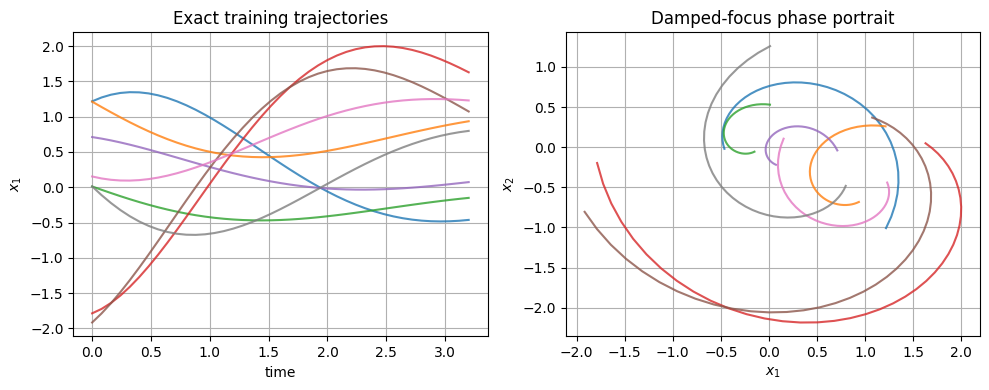

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
t_train = torch.arange(cfg.train_steps + 1) * cfg.h
for i in range(min(8, cfg.n_train)):
    axes[0].plot(t_train, train_data['x'][i, :, 0], alpha=0.8)
    axes[1].plot(train_data['x'][i, :, 0], train_data['x'][i, :, 1], alpha=0.8)
axes[0].set(xlabel='time', ylabel='$x_1$', title='Exact training trajectories')
axes[1].set(xlabel='$x_1$', ylabel='$x_2$', title='Damped-focus phase portrait')
plt.tight_layout()

## 3. FTNODE model

The public FTNODE builder constructs the registered `svd_clamp + grad_potential` pair. Only its fully observed `dynamics` module is trained; the builder's encoder and decoder are intentionally unused. Passing `cap=False` makes $\Phi$ a free potential—none of its weight matrices are projected or spectrally capped. The SVD clamp on $A$ remains active at every field evaluation.

In [16]:
budget = KappaBudget(
    sigma_min=cfg.sigma_min,
    kappa_max=cfg.kappa_max,
    skew_frac=cfg.skew_frac,
    m=2,
)
model_cfg = LatentModelConfig(
    m=2,
    q=1,
    activation='tanh',
    encoder=EncoderConfig(tau=1, hidden=cfg.hidden, depth=1, z_scale=cfg.x0_box),
    operator=OperatorConfig(
        kind='svd_clamp', hidden=cfg.hidden, depth=cfg.depth, sigma_min=cfg.sigma_min
    ),
    equilibrium=EquilibriumConfig(
        kind='grad_potential',
        hidden=cfg.hidden,
        depth=cfg.depth,
        kwargs={'cap': False, 'init_scale': 0.25},
    ),
)

# Re-seed so model initialization is independent of dataset generation.
set_global_seed(cfg.seed)
assembled = build_latent_ftnode(model_cfg, budget, clamp_fn=spectral_clamp)
model = assembled.dynamics.to(device)

assert model.operator.__class__.__name__ == 'ClampOperator'
assert model.equilibrium.__class__.__name__ == 'GradPotentialG'
assert model.equilibrium.cap is False
assert np.isinf(model.equilibrium.g_bound)
print(model)
print(f'trainable dynamics parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'A budgets: sigma_min={budget.sigma_min:.3g}, c_P={budget.c_P:.3g}, '
      f'c_K={budget.c_K:.3g}, kappa_max={budget.kappa_max:.3g}')
print('potential cap:', model.equilibrium.cap, '| g bound:', model.equilibrium.g_bound)

[Seed] Deterministic mode enabled (may reduce speed).
LatentFTNODE(
  (operator): ClampOperator(
    (L_net): MLP(
      (net): Sequential(
        (0): Linear(in_features=2, out_features=32, bias=True)
        (1): Tanh()
        (2): Linear(in_features=32, out_features=32, bias=True)
        (3): Tanh()
        (4): Linear(in_features=32, out_features=4, bias=True)
      )
    )
    (S_net): MLP(
      (net): Sequential(
        (0): Linear(in_features=2, out_features=32, bias=True)
        (1): Tanh()
        (2): Linear(in_features=32, out_features=32, bias=True)
        (3): Tanh()
        (4): Linear(in_features=32, out_features=4, bias=True)
      )
    )
  )
  (equilibrium): GradPotentialG(
    (net): Sequential(
      (0): Linear(in_features=3, out_features=32, bias=True)
      (1): Tanh()
      (2): Linear(in_features=32, out_features=32, bias=True)
      (3): Tanh()
      (4): Linear(in_features=32, out_features=1, bias=True)
    )
  )
)
trainable dynamics parameters: 3,785


## 4. Train from trajectories

The loss is state MSE over RK4 rollouts. There is no vector-field supervision, equilibrium label, or residual penalty. Validation is deliberately longer than the training horizon, testing asymptotic extrapolation. The best validation state is retained in memory, so the notebook creates no checkpoints or other files.

In [17]:
def model_rollout(dynamics, x0: torch.Tensor, u: torch.Tensor, steps: int, h: float):
    x = x0
    xs = [x]
    for _ in range(steps):
        x = rk4_step(dynamics.F, x, u, h)
        xs.append(x)
    return torch.stack(xs, dim=1)

def to_device(data: dict[str, torch.Tensor]) -> dict[str, torch.Tensor]:
    return {key: value.to(device) for key, value in data.items()}

def fit_from_trajectories(dynamics, train, val, config):
    train = to_device(train)
    val = to_device(val)
    optimizer = torch.optim.Adam(dynamics.parameters(), lr=config.lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.epochs)
    history = {'epoch': [], 'train_mse': [], 'val_mse': [], 'grad_norm': []}
    best_val = float('inf')
    best_state = None
    start = time.time()

    for epoch in range(config.epochs):
        dynamics.train()
        permutation = torch.randperm(train['x0'].shape[0], device=device)
        epoch_loss = []
        epoch_grad = []
        for begin in range(0, len(permutation), config.batch_size):
            idx = permutation[begin:begin + config.batch_size]
            prediction = model_rollout(
                dynamics, train['x0'][idx], train['u'][idx], config.train_steps, config.h
            )
            loss = torch.mean((prediction - train['x'][idx]) ** 2)
            if not torch.isfinite(loss):
                raise FloatingPointError(f'non-finite training loss at epoch {epoch}')
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(dynamics.parameters(), config.grad_clip)
            optimizer.step()
            epoch_loss.append(loss.detach().item())
            epoch_grad.append(float(grad_norm))
        scheduler.step()

        should_eval = epoch % config.eval_every == 0 or epoch == config.epochs - 1
        if should_eval:
            dynamics.eval()
            with torch.no_grad():
                val_prediction = model_rollout(
                    dynamics, val['x0'], val['u'], config.eval_steps, config.h
                )
                val_loss = torch.mean((val_prediction - val['x']) ** 2).item()
            history['epoch'].append(epoch)
            history['train_mse'].append(float(np.mean(epoch_loss)))
            history['val_mse'].append(val_loss)
            history['grad_norm'].append(float(np.mean(epoch_grad)))
            if val_loss < best_val:
                best_val = val_loss
                best_state = {k: v.detach().cpu().clone() for k, v in dynamics.state_dict().items()}
            if epoch % max(20, config.eval_every) == 0 or epoch == config.epochs - 1:
                print(
                    f'epoch {epoch:4d} | train {history["train_mse"][-1]:.3e} | '
                    f'long-val {val_loss:.3e} | {time.time() - start:.1f}s'
                )

    if best_state is None:
        raise RuntimeError('training completed without a finite validation state')
    dynamics.load_state_dict(best_state)
    dynamics.eval()
    history['best_val'] = best_val
    return history

history = fit_from_trajectories(model, train_data, val_data, cfg)
print(f'best long-horizon validation MSE: {history["best_val"]:.4e}')

epoch    0 | train 1.162e+00 | long-val 4.759e-01 | 3.2s
epoch   20 | train 3.745e-02 | long-val 2.446e-02 | 53.5s
epoch   40 | train 1.789e-02 | long-val 1.150e-02 | 103.1s
epoch   60 | train 1.193e-02 | long-val 8.402e-03 | 151.7s
epoch   80 | train 8.795e-03 | long-val 6.562e-03 | 201.8s
epoch  100 | train 6.558e-03 | long-val 4.755e-03 | 251.0s
epoch  120 | train 5.095e-03 | long-val 3.979e-03 | 299.1s
epoch  140 | train 4.033e-03 | long-val 3.296e-03 | 348.0s
epoch  160 | train 3.305e-03 | long-val 2.807e-03 | 396.5s
epoch  180 | train 2.836e-03 | long-val 2.614e-03 | 445.4s
epoch  200 | train 2.614e-03 | long-val 2.518e-03 | 492.3s
epoch  220 | train 2.518e-03 | long-val 2.487e-03 | 540.8s
epoch  240 | train 2.492e-03 | long-val 2.471e-03 | 587.8s
epoch  249 | train 2.491e-03 | long-val 2.470e-03 | 609.3s
best long-horizon validation MSE: 2.4702e-03


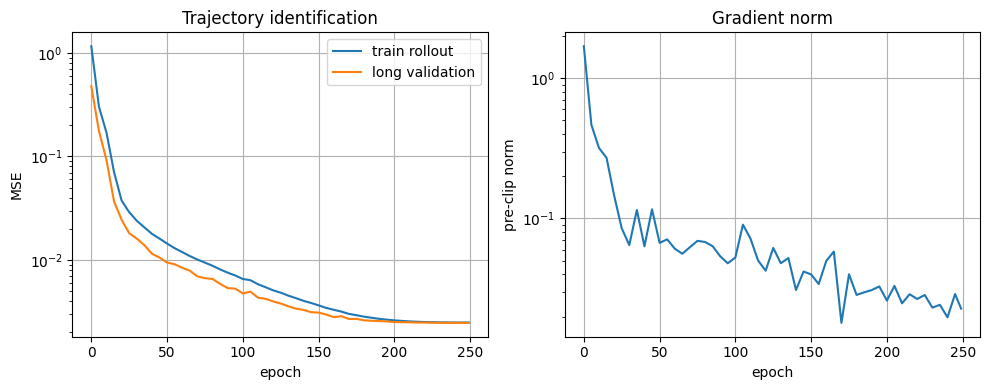

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].semilogy(history['epoch'], history['train_mse'], label='train rollout')
axes[0].semilogy(history['epoch'], history['val_mse'], label='long validation')
axes[0].set(xlabel='epoch', ylabel='MSE', title='Trajectory identification')
axes[0].legend()
axes[1].semilogy(history['epoch'], history['grad_norm'])
axes[1].set(xlabel='epoch', ylabel='pre-clip norm', title='Gradient norm')
plt.tight_layout()

## 5. Rollout and asymptotic steady-state diagnostics

probe rollout RMSE: 5.2598e-02


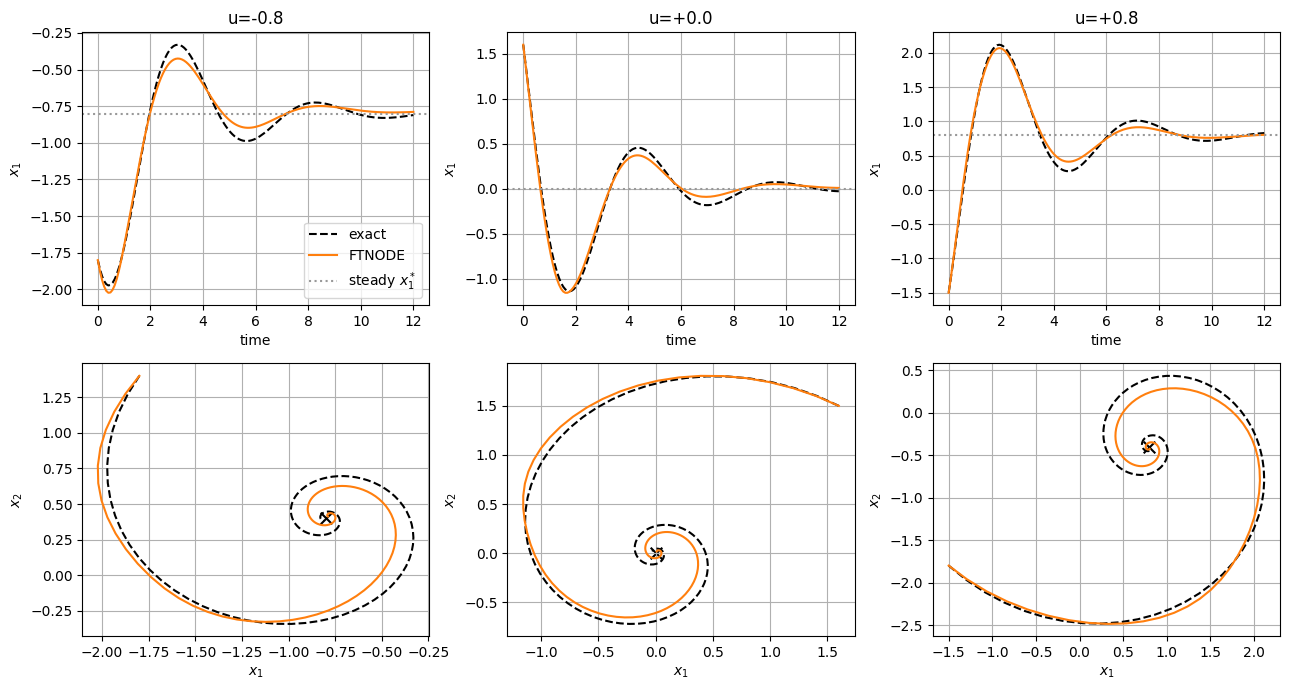

In [19]:
probe_u = torch.tensor([-0.8, 0.0, 0.8], device=device)
probe_x0 = torch.tensor([[-1.8, 1.4], [1.6, 1.5], [-1.5, -1.8]], device=device)
probe_steps = cfg.eval_steps
with torch.no_grad():
    learned_probe = model_rollout(model, probe_x0, probe_u, probe_steps, cfg.h).cpu()
    exact_probe = exact_rollout(probe_x0, probe_u, probe_steps, cfg.h).cpu()
probe_u_cpu = probe_u.cpu()
probe_t = torch.arange(probe_steps + 1) * cfg.h
probe_rmse = torch.mean((learned_probe - exact_probe) ** 2).sqrt().item()
print(f'probe rollout RMSE: {probe_rmse:.4e}')

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for j, u_value in enumerate(probe_u_cpu):
    axes[0, j].plot(probe_t, exact_probe[j, :, 0], 'k--', label='exact')
    axes[0, j].plot(probe_t, learned_probe[j, :, 0], color='C1', label='FTNODE')
    axes[0, j].axhline(float(u_value), color='0.6', ls=':', label='steady $x_1^*$')
    axes[0, j].set(title=f'u={u_value.item():+.1f}', xlabel='time', ylabel='$x_1$')
    axes[1, j].plot(exact_probe[j, :, 0], exact_probe[j, :, 1], 'k--')
    axes[1, j].plot(learned_probe[j, :, 0], learned_probe[j, :, 1], color='C1')
    exact_eq = true_steady_state(u_value.reshape(1)).squeeze(0)
    axes[1, j].scatter(*exact_eq, c='k', marker='x', s=70)
    axes[1, j].set(xlabel='$x_1$', ylabel='$x_2$')
axes[0, 0].legend(loc='best')
plt.tight_layout()

max steady-state error:       7.0636e-02
mean steady-state error:      2.3587e-02
max terminal start spread:    6.0941e-04
max learned field residual:   2.5430e-04


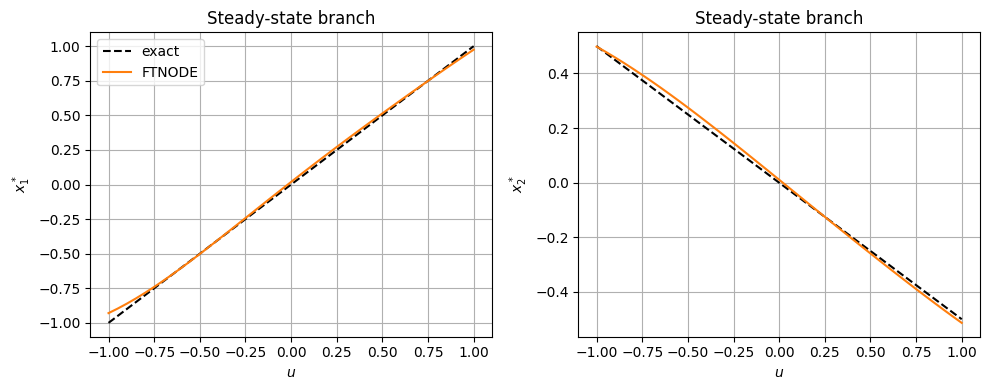

In [20]:
u_grid = torch.linspace(-cfg.u_max, cfg.u_max, 41, device=device)
starts = torch.tensor([[-2.0, -2.0], [-2.0, 2.0], [2.0, -2.0], [2.0, 2.0]], device=device)
u_repeated = u_grid.repeat_interleave(len(starts))
x0_repeated = starts.repeat(len(u_grid), 1)
steady_steps = max(cfg.eval_steps, 250)
with torch.no_grad():
    terminal = model_rollout(model, x0_repeated, u_repeated, steady_steps, cfg.h)[:, -1]
    terminal_grouped = terminal.reshape(len(u_grid), len(starts), 2)
    learned_eq = terminal_grouped.mean(dim=1)
    start_spread = (terminal_grouped - learned_eq[:, None]).norm(dim=-1).max(dim=1).values
    exact_eq = true_steady_state(u_grid)
    equilibrium_error = (learned_eq - exact_eq).norm(dim=-1)
    equilibrium_residual = model.F(learned_eq, u_grid).norm(dim=-1)

print(f'max steady-state error:       {equilibrium_error.max().item():.4e}')
print(f'mean steady-state error:      {equilibrium_error.mean().item():.4e}')
print(f'max terminal start spread:    {start_spread.max().item():.4e}')
print(f'max learned field residual:   {equilibrium_residual.max().item():.4e}')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for coordinate in range(2):
    axes[coordinate].plot(u_grid.cpu(), exact_eq[:, coordinate].cpu(), 'k--', label='exact')
    axes[coordinate].plot(u_grid.cpu(), learned_eq[:, coordinate].cpu(), color='C1', label='FTNODE')
    axes[coordinate].set(xlabel='$u$', ylabel=f'$x_{coordinate + 1}^*$', title='Steady-state branch')
axes[0].legend()
plt.tight_layout()

## 6. Structural diagnostics

These checks distinguish a good trajectory fit from the intended model mechanism:

- $\operatorname{sym}A\preceq-\sigma_{\min}I$ and $\kappa(A)\leq\kappa_{\max}$;
- $J_g=J_g^\top$ to numerical precision;
- continuous-time dissipation $\dot V\leq-\sigma_{\min}\lVert\nabla V\rVert^2$;
- non-increase of $V$ under the finite-step RK4 rollout (a monitored numerical property, not a theorem);
- locally stable learned equilibria.

In [21]:
with torch.no_grad():
    val_x0 = val_data['x0'].to(device)
    val_u = val_data['u'].to(device)
    learned_val = model_rollout(model, val_x0, val_u, cfg.eval_steps, cfg.h)
    sample_stride = max(1, cfg.eval_steps // 25)
    Z = learned_val[:, ::sample_stride].reshape(-1, 2)
    U = val_u[:, None].expand(-1, learned_val[:, ::sample_stride].shape[1]).reshape(-1)
    A = model.A(Z)
    sym_A = 0.5 * (A + A.transpose(-1, -2))
    sigma_max = torch.linalg.svdvals(A)[:, 0]
    contraction = -torch.linalg.eigvalsh(sym_A)[:, -1]
    kappa = sigma_max / contraction.clamp_min(1e-12)
    max_real_A = torch.linalg.eigvals(A).real.max(dim=-1).values

def g_single(z, u):
    return model.g(z.unsqueeze(0), u.reshape(1)).squeeze(0)

Jg = vmap(jacrev(g_single, argnums=0))(Z, U).detach()
skew_Jg = 0.5 * (Jg - Jg.transpose(-1, -2))
skew_fraction = skew_Jg.flatten(1).norm(dim=1) / Jg.flatten(1).norm(dim=1).clamp_min(1e-12)

with torch.no_grad():
    grad_V = Z - model.g(Z, U)
    field = model.F(Z, U)
    Vdot = (grad_V * field).sum(dim=-1)
    dissipation_margin = Vdot + cfg.sigma_min * grad_V.square().sum(dim=-1)

def potential_V(z, u):
    return 0.5 * z.square().sum(dim=-1) - model.equilibrium.phi(z, u)

with torch.no_grad():
    rollout_u = val_u[:, None].expand(-1, learned_val.shape[1])
    V_along = potential_V(learned_val, rollout_u)
    delta_V = V_along[:, 1:] - V_along[:, :-1]

def field_single(z, u):
    return model.F(z.unsqueeze(0), u.reshape(1)).squeeze(0)

J_equilibrium = vmap(jacrev(field_single, argnums=0))(learned_eq, u_grid).detach()
eq_eigenvalues = torch.linalg.eigvals(J_equilibrium)

checks = {
    'max Re eig(A)': max_real_A.max().item(),
    'min contraction of -sym(A)': contraction.min().item(),
    'max sigma(A)': sigma_max.max().item(),
    'max kappa(A)': kappa.max().item(),
    'max skew fraction of J_g': skew_fraction.max().item(),
    'max continuous dissipation margin': dissipation_margin.max().item(),
    'max RK4 step Delta V': delta_V.max().item(),
    'max Re eig(dF/dz) at learned equilibria': eq_eigenvalues.real.max().item(),
}
for name, value in checks.items():
    print(f'{name:46s} {value: .6e}')

assert contraction.min() >= cfg.sigma_min - 5e-5
assert kappa.max() <= cfg.kappa_max + 5e-4
assert skew_fraction.max() < 1e-4
assert dissipation_margin.max() <= 5e-5

max Re eig(A)                                  -3.823346e-01
min contraction of -sym(A)                      2.000000e-01
max sigma(A)                                    1.614805e+00
max kappa(A)                                    8.074027e+00
max skew fraction of J_g                        1.995322e-07
max continuous dissipation margin              -4.888591e-09
max RK4 step Delta V                            3.576279e-07
max Re eig(dF/dz) at learned equilibria        -4.387892e-01


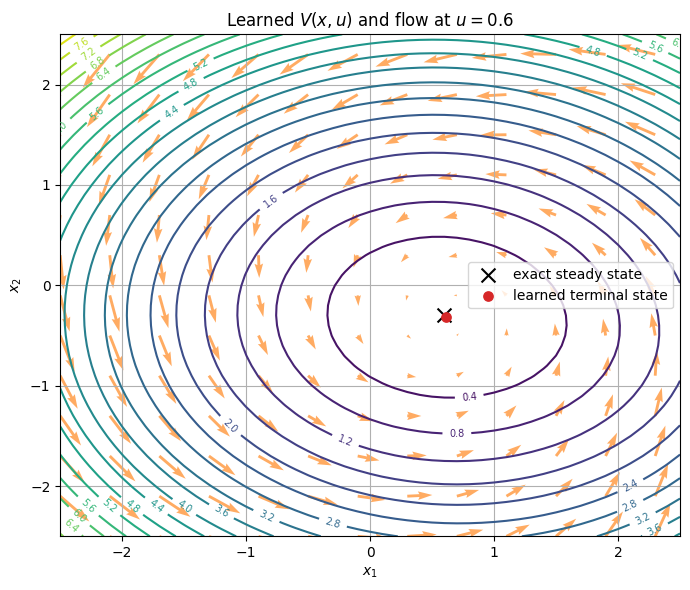

In [22]:
# Potential landscape and learned flow for one frozen input.
landscape_u = 0.6
axis = torch.linspace(-2.5, 2.5, 51, device=device)
xx, yy = torch.meshgrid(axis, axis, indexing='xy')
grid = torch.stack([xx.reshape(-1), yy.reshape(-1)], dim=-1)
grid_u = torch.full((len(grid),), landscape_u, device=device)
with torch.no_grad():
    V_grid = potential_V(grid, grid_u).reshape(xx.shape).cpu()
    F_grid = model.F(grid, grid_u).reshape(*xx.shape, 2).cpu()
    true_eq_landscape = true_steady_state(torch.tensor([landscape_u], device=device)).cpu()[0]
    learned_eq_landscape = model_rollout(
        model, torch.zeros(1, 2, device=device), torch.tensor([landscape_u], device=device),
        steady_steps, cfg.h,
    )[0, -1].cpu()

fig, ax = plt.subplots(figsize=(7, 6))
contours = ax.contour(xx.cpu(), yy.cpu(), V_grid, levels=25, cmap='viridis')
ax.clabel(contours, inline=True, fontsize=7)
skip = (slice(None, None, 4), slice(None, None, 4))
ax.quiver(
    xx.cpu()[skip], yy.cpu()[skip], F_grid[..., 0][skip], F_grid[..., 1][skip],
    color='C1', alpha=0.65,
)
ax.scatter(*true_eq_landscape, marker='x', s=100, c='k', label='exact steady state')
ax.scatter(*learned_eq_landscape, marker='o', s=45, c='C3', label='learned terminal state')
ax.set(xlabel='$x_1$', ylabel='$x_2$', title=f'Learned $V(x,u)$ and flow at $u={landscape_u}$')
ax.legend()
plt.tight_layout()

## 7. Interpretation and scope

For frozen $u$, symmetry gives the continuous-time identity

$$\dot V=\langle\nabla V,A\nabla V\rangle
=\langle\nabla V,\operatorname{sym}(A)\nabla V\rangle
\leq-\sigma_{\min}\lVert\nabla V\rVert^2.$$

This benchmark needs only one attracting minimum for each input; it does not test saddle formation or multistability. Because the potential is uncapped, the $J_g$ symmetry, Morse/inertia result, and Lyapunov dissipation survive, while the explicit global trapping radius requiring an a-priori bound on $\lVert g\rVert_2$ does not. Finally, monotonicity of $V$ is a continuous-time guarantee. `max RK4 step Delta V` reports whether the chosen finite step preserved it on these rollouts rather than assuming that it did.

A(0) =
 [[-0.49402398 -0.99119097]
 [ 1.5288095  -0.44623816]]
u=-0.8: g(0,u)=[-0.61000156  0.46852744], grad V(0,u)=[ 0.61000156 -0.46852744]
u=+0.0: g(0,u)=[0.01522677 0.01272991], grad V(0,u)=[-0.01522677 -0.01272991]
u=+0.8: g(0,u)=[ 0.63342667 -0.4439031 ], grad V(0,u)=[-0.63342667  0.4439031 ]


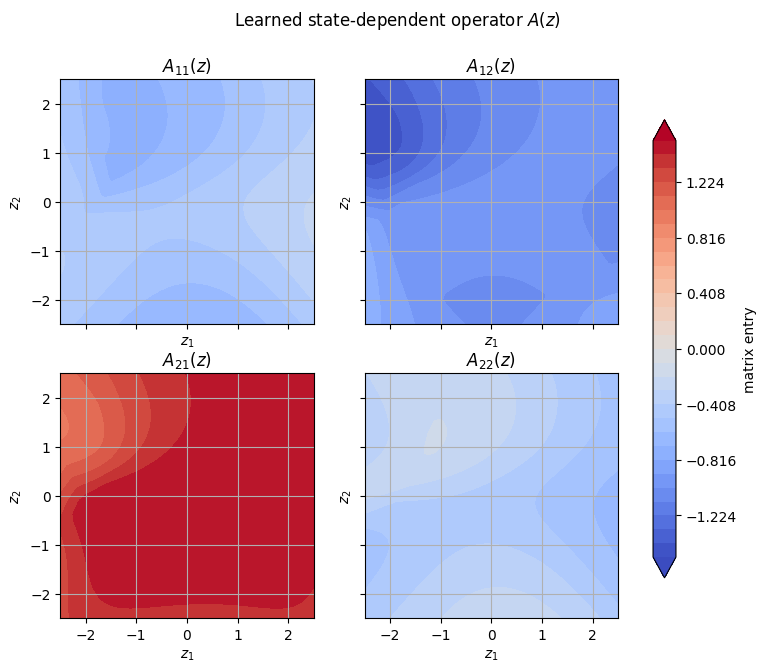

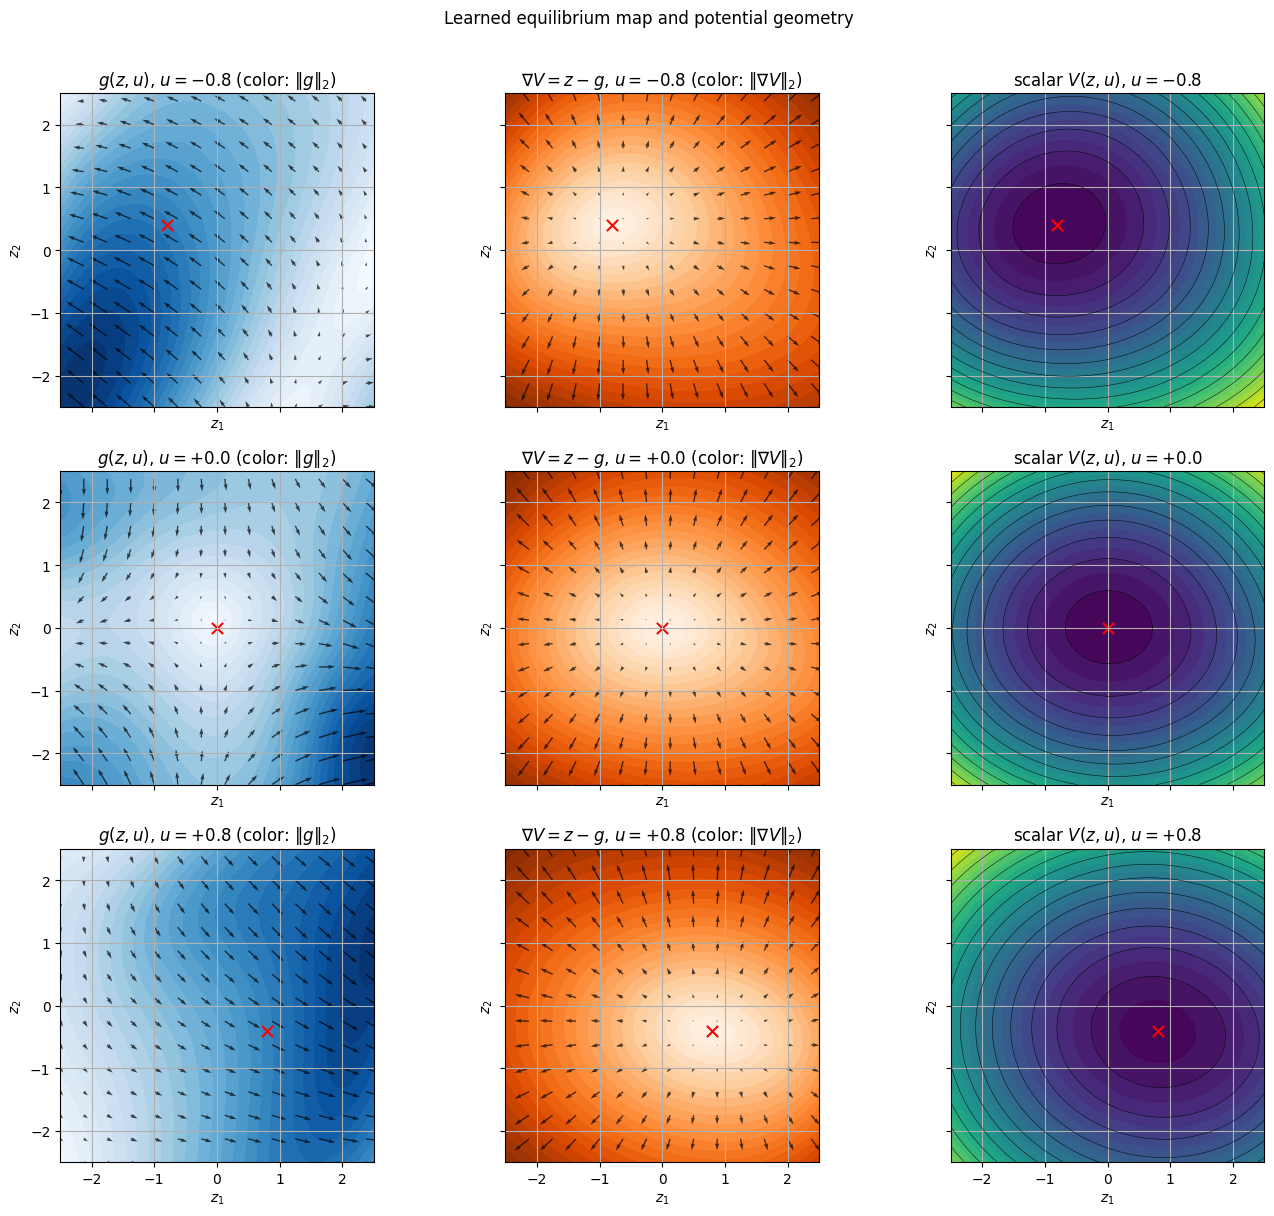

In [27]:

diagnostic_axis = torch.linspace(-2.5, 2.5, 41, device=device)
dxx, dyy = torch.meshgrid(diagnostic_axis, diagnostic_axis, indexing="xy")
diagnostic_grid = torch.stack(
    [dxx.reshape(-1), dyy.reshape(-1)], dim=-1
)

with torch.no_grad():
    learned_A = model.A(diagnostic_grid).reshape(*dxx.shape, 2, 2).cpu()

# # A does not depend on u in this architecture. Plot every entry over state space.
# A_limit = learned_A.abs().max().item()
# fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True, sharey=True)

# for row in range(2):
#     for col in range(2):
#         image = axes[row, col].contourf(
#             dxx.cpu(),
#             dyy.cpu(),
#             learned_A[..., row, col],
#             levels=31,
#             cmap="coolwarm",
#             vmin=-A_limit,
#             vmax=A_limit,
#         )
#         axes[row, col].set(
#             title=fr"$A_{{{row + 1}{col + 1}}}(z)$",
#             xlabel="$z_1$",
#             ylabel="$z_2$",
#         )

# fig.colorbar(
#     image,
#     ax=axes.ravel().tolist(),
#     shrink=0.85,
#     label="matrix entry",
# )
# fig.suptitle("Learned state-dependent operator $A(z)$")

A_limit = learned_A.abs().max().item()
A_levels = np.linspace(-A_limit, A_limit, 31)

fig, axes = plt.subplots(2, 2, figsize=(9, 7), sharex=True, sharey=True)

for row in range(2):
    for col in range(2):
        image = axes[row, col].contourf(
            dxx.cpu(),
            dyy.cpu(),
            learned_A[..., row, col],
            levels=A_levels,
            cmap="coolwarm",
            extend="both",
        )
        axes[row, col].set(
            title=fr"$A_{{{row + 1}{col + 1}}}(z)$",
            xlabel="$z_1$",
            ylabel="$z_2$",
        )

fig.colorbar(
    image,
    ax=axes.ravel().tolist(),
    shrink=0.85,
    label="matrix entry",
)
fig.suptitle("Learned state-dependent operator $A(z)$")


diagnostic_controls = (-0.8, 0.0, 0.8)
arrow_skip = (slice(None, None, 3), slice(None, None, 3))

fig, axes = plt.subplots(
    len(diagnostic_controls),
    3,
    figsize=(14, 12),
    sharex=True,
    sharey=True,
)

for row, u_value in enumerate(diagnostic_controls):
    diagnostic_u = torch.full(
        (len(diagnostic_grid),),
        u_value,
        device=device,
    )

    with torch.no_grad():
        learned_g = (
            model.g(diagnostic_grid, diagnostic_u)
            .reshape(*dxx.shape, 2)
            .cpu()
        )
        grad_V = (
            diagnostic_grid.cpu().reshape(*dxx.shape, 2) - learned_g
        )
        scalar_V = (
            potential_V(diagnostic_grid, diagnostic_u)
            .reshape(dxx.shape)
            .cpu()
        )
        exact_eq = true_steady_state(
            torch.tensor([u_value], device=device)
        ).cpu()[0]

    g_norm = learned_g.norm(dim=-1)
    axes[row, 0].contourf(
        dxx.cpu(),
        dyy.cpu(),
        g_norm,
        levels=25,
        cmap="Blues",
    )
    axes[row, 0].quiver(
        dxx.cpu()[arrow_skip],
        dyy.cpu()[arrow_skip],
        learned_g[..., 0][arrow_skip],
        learned_g[..., 1][arrow_skip],
        color="k",
        alpha=0.7,
    )
    axes[row, 0].set_title(
        fr"$g(z,u)$, $u={u_value:+.1f}$ "
        fr"(color: $\Vert g\Vert_2$)"
    )

    grad_norm = grad_V.norm(dim=-1)
    axes[row, 1].contourf(
        dxx.cpu(),
        dyy.cpu(),
        grad_norm,
        levels=25,
        cmap="Oranges",
    )
    axes[row, 1].quiver(
        dxx.cpu()[arrow_skip],
        dyy.cpu()[arrow_skip],
        grad_V[..., 0][arrow_skip],
        grad_V[..., 1][arrow_skip],
        color="k",
        alpha=0.7,
    )
    axes[row, 1].set_title(
        fr"$\nabla V=z-g$, $u={u_value:+.1f}$ "
        fr"(color: $\Vert\nabla V\Vert_2$)"
    )

    axes[row, 2].contourf(
        dxx.cpu(),
        dyy.cpu(),
        scalar_V,
        levels=30,
        cmap="viridis",
    )
    axes[row, 2].contour(
        dxx.cpu(),
        dyy.cpu(),
        scalar_V,
        levels=15,
        colors="k",
        linewidths=0.35,
    )
    axes[row, 2].set_title(
        fr"scalar $V(z,u)$, $u={u_value:+.1f}$"
    )

    for ax in axes[row]:
        ax.scatter(
            *exact_eq,
            marker="x",
            s=65,
            c="red",
        )
        ax.set(
            xlabel="$z_1$",
            ylabel="$z_2$",
            aspect="equal",
        )

fig.suptitle(
    "Learned equilibrium map and potential geometry",
    y=1.01,
)
plt.tight_layout()

origin = torch.zeros(1, 2, device=device)

with torch.no_grad():
    print(
        "A(0) =\n",
        model.A(origin).squeeze(0).cpu().numpy(),
    )

    for u_value in diagnostic_controls:
        u_tensor = torch.tensor([u_value], device=device)
        g_at_origin = (
            model.g(origin, u_tensor)
            .squeeze(0)
            .cpu()
            .numpy()
        )
        print(
            f"u={u_value:+.1f}: "
            f"g(0,u)={g_at_origin}, "
            f"grad V(0,u)={-g_at_origin}"
        )

### Held-out test protocol

Generate test trajectories with a third, fixed RNG seed that is distinct from the training and validation seeds. Evaluate this set only after training and model selection are complete; do not use its metrics to choose epochs or tune hyperparameters. The standalone test cell provided with this notebook uses `cfg.seed + 303`.

held-out trajectories:       64
held-out RNG seed:           310
full-rollout RMSE:           4.937216e-02
x1 RMSE:                     5.017935e-02
x2 RMSE:                     4.855155e-02
terminal-state RMSE:         1.867701e-02
terminal-to-equilibrium RMSE:1.947837e-02
x1 R2:                       0.994649
x2 R2:                       0.990965


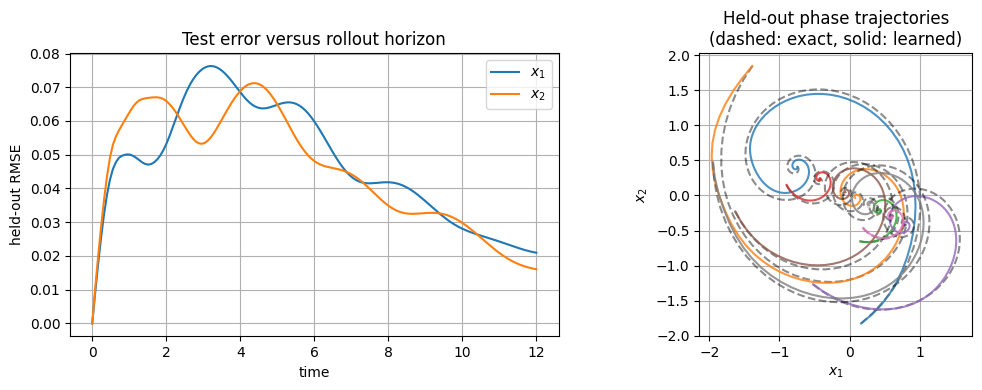

In [26]:
# Final held-out test: do not use these results for tuning or model selection.
N_TEST = 64
TEST_SEED = cfg.seed + 303

assert TEST_SEED not in (cfg.seed + 101, cfg.seed + 202)

test_data = make_dataset(
    n=N_TEST,
    steps=cfg.eval_steps,
    seed=TEST_SEED,
)

test_x0 = test_data["x0"].to(device)
test_u = test_data["u"].to(device)
test_true = test_data["x"].to(device)

model.eval()
with torch.no_grad():
    test_prediction = model_rollout(
        model,
        test_x0,
        test_u,
        cfg.eval_steps,
        cfg.h,
    )

test_error = test_prediction - test_true

test_rmse = test_error.square().mean().sqrt()
state_rmse = test_error.square().mean(dim=(0, 1)).sqrt()
terminal_rmse = test_error[:, -1].square().mean().sqrt()

true_test_equilibria = true_steady_state(test_u)
steady_state_rmse = (
    test_prediction[:, -1] - true_test_equilibria
).square().mean().sqrt()

squared_residual = test_error.square().sum(dim=(0, 1))
centered_truth = test_true - test_true.mean(
    dim=(0, 1),
    keepdim=True,
)
squared_total = centered_truth.square().sum(dim=(0, 1))
state_r2 = 1.0 - squared_residual / squared_total.clamp_min(1e-12)

time_rmse = test_error.square().mean(dim=0).sqrt()
test_time = torch.arange(
    cfg.eval_steps + 1,
    device=device,
) * cfg.h

print(f"held-out trajectories:       {N_TEST}")
print(f"held-out RNG seed:           {TEST_SEED}")
print(f"full-rollout RMSE:           {test_rmse.item():.6e}")
print(f"x1 RMSE:                     {state_rmse[0].item():.6e}")
print(f"x2 RMSE:                     {state_rmse[1].item():.6e}")
print(f"terminal-state RMSE:         {terminal_rmse.item():.6e}")
print(f"terminal-to-equilibrium RMSE:{steady_state_rmse.item():.6e}")
print(f"x1 R2:                       {state_r2[0].item():.6f}")
print(f"x2 R2:                       {state_r2[1].item():.6f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(
    test_time.cpu(),
    time_rmse[:, 0].cpu(),
    label="$x_1$",
)
axes[0].plot(
    test_time.cpu(),
    time_rmse[:, 1].cpu(),
    label="$x_2$",
)
axes[0].set(
    xlabel="time",
    ylabel="held-out RMSE",
    title="Test error versus rollout horizon",
)
axes[0].legend()

for index in range(min(8, N_TEST)):
    axes[1].plot(
        test_true[index, :, 0].cpu(),
        test_true[index, :, 1].cpu(),
        "k--",
        alpha=0.45,
    )
    axes[1].plot(
        test_prediction[index, :, 0].cpu(),
        test_prediction[index, :, 1].cpu(),
        color=f"C{index % 10}",
        alpha=0.8,
    )

axes[1].set(
    xlabel="$x_1$",
    ylabel="$x_2$",
    title="Held-out phase trajectories\n(dashed: exact, solid: learned)",
    aspect="equal",
)

plt.tight_layout()